# 06 - Multiplicative Attention (Luong)
Decoder attends over encoder states via a dot-product/bilinear alignment score.

In [1]:
import sys, os, json, pickle, random, math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

sys.path.append("../src")
import config
from dataset import TranslationDataset, create_collate_fn
from models.luong_attention import LuongAttention, EncoderLuongLSTM, DecoderLuongLSTM, Seq2SeqLuongAttention
from train import train_epoch, evaluate
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from evaluate import translate_sentence

random.seed(config.ROLL_NUMBER)
np.random.seed(config.ROLL_NUMBER)
torch.manual_seed(config.ROLL_NUMBER)
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: mps


## Load data

In [2]:
train_df = pd.read_csv("../data/processed/train.csv")
val_df = pd.read_csv("../data/processed/validation.csv")
test_df = pd.read_csv("../data/processed/test.csv")

english_vocab = pickle.load(open("../data/processed/english_vocab.pkl", "rb"))
spanish_vocab = pickle.load(open("../data/processed/spanish_vocab.pkl", "rb"))

pad_en = english_vocab.word2idx["<pad>"]
pad_es = spanish_vocab.word2idx["<pad>"]
collate_fn = create_collate_fn(pad_en, pad_es)

train_dataset = TranslationDataset(train_df, english_vocab, spanish_vocab)
val_dataset = TranslationDataset(val_df, english_vocab, spanish_vocab)
test_dataset = TranslationDataset(test_df, english_vocab, spanish_vocab)

train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

## Build model

In [3]:
MODEL_NAME = "Multiplicative Attention (Luong)"
MODEL_KEY = "luong_attention"
CHECKPOINT_PATH = "../models/luong_attention_model.pt"

attention = LuongAttention(config.HIDDEN_DIM)
encoder = EncoderLuongLSTM(len(english_vocab), config.EMB_DIM, config.HIDDEN_DIM, dropout_p=config.DROPOUT)
decoder = DecoderLuongLSTM(len(spanish_vocab), config.EMB_DIM, config.HIDDEN_DIM, attention, dropout_p=config.DROPOUT)
model = Seq2SeqLuongAttention(encoder, decoder, device).to(device)

## Train

In [4]:
criterion = nn.CrossEntropyLoss(ignore_index=pad_es)
optimizer = optim.Adam(model.parameters(), lr=config.LEARNING_RATE)
print("Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

best_val_loss = float("inf")
os.makedirs("../models", exist_ok=True)
history = {"train_loss": [], "val_loss": []}

for epoch in range(config.N_EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device, teacher_forcing_ratio=config.TEACHER_FORCING_RATIO)
    val_loss = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CHECKPOINT_PATH)

    print(f"Epoch: {epoch+1:02} | Train Loss: {train_loss:.3f} | Val Loss: {val_loss:.3f}")

Trainable params: 3804210
Epoch: 01 | Train Loss: 5.077 | Val Loss: 4.507
Epoch: 02 | Train Loss: 4.245 | Val Loss: 4.087
Epoch: 03 | Train Loss: 3.772 | Val Loss: 3.795
Epoch: 04 | Train Loss: 3.408 | Val Loss: 3.453
Epoch: 05 | Train Loss: 3.100 | Val Loss: 3.294
Epoch: 06 | Train Loss: 2.842 | Val Loss: 3.138
Epoch: 07 | Train Loss: 2.613 | Val Loss: 3.091
Epoch: 08 | Train Loss: 2.435 | Val Loss: 3.013
Epoch: 09 | Train Loss: 2.274 | Val Loss: 2.946
Epoch: 10 | Train Loss: 2.159 | Val Loss: 2.877


## Loss curve

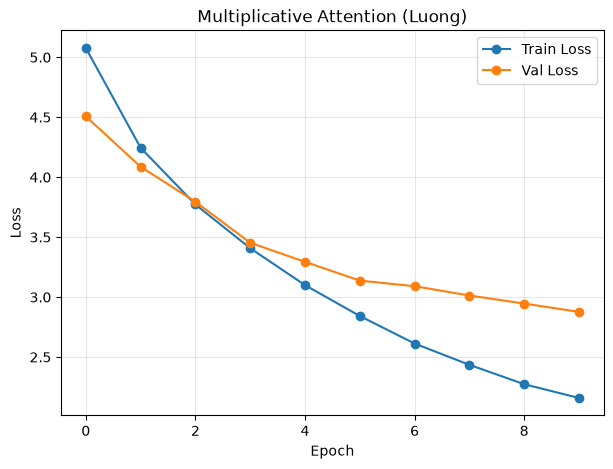

In [5]:
plt.figure(figsize=(7, 5))
plt.plot(history["train_loss"], label="Train Loss", marker="o")
plt.plot(history["val_loss"], label="Val Loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(MODEL_NAME)
plt.legend()
plt.grid(alpha=0.3)
os.makedirs("../results/figures", exist_ok=True)
plt.savefig(f"../results/figures/{MODEL_KEY}_loss.png", dpi=150, bbox_inches="tight")
plt.show()

## Test evaluation

In [6]:
# Load optimal checkpoint weights
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))

test_loss = evaluate(model, test_loader, criterion, device)
test_ppl = math.exp(test_loss)

print(f"Test Loss: {test_loss:.3f}")
print(f"Test Perplexity: {test_ppl:.3f}")

smooth = SmoothingFunction().method1
references = []
hypotheses = []

for _, row in test_df.iterrows():
    src_text = row["english"]
    trg_text = row["spanish"]

    pred_text, _ = translate_sentence(src_text, english_vocab, spanish_vocab, model, device, max_len=config.MAX_DECODE_LEN)

    references.append([spanish_vocab.tokenize(trg_text)])
    hypotheses.append(pred_text.split())

bleu1 = corpus_bleu(references, hypotheses, weights=(1.0, 0, 0, 0), smoothing_function=smooth) * 100
bleu4 = corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth) * 100

print(f"{MODEL_NAME} Corpus BLEU-1 Score: {bleu1:.2f}")
print(f"{MODEL_NAME} Corpus BLEU-4 Score: {bleu4:.2f}")

results = {
    "model": MODEL_NAME,
    "params": sum(p.numel() for p in model.parameters() if p.requires_grad),
    "test_loss": round(test_loss, 3),
    "test_ppl": round(test_ppl, 3),
    "bleu1": round(bleu1, 2),
    "bleu4": round(bleu4, 2),
}
print(results)

os.makedirs("../results/tables", exist_ok=True)
json.dump(results, open(f"../results/tables/{MODEL_KEY}_results.json", "w"))
json.dump(history, open(f"../results/tables/{MODEL_KEY}_history.json", "w"))

Test Loss: 2.970
Test Perplexity: 19.496
Multiplicative Attention (Luong) Corpus BLEU-1 Score: 55.19
Multiplicative Attention (Luong) Corpus BLEU-4 Score: 18.76
{'model': 'Multiplicative Attention (Luong)', 'params': 3804210, 'test_loss': 2.97, 'test_ppl': 19.496, 'bleu1': 55.19, 'bleu4': 18.76}


## Sample translations

In [7]:
samples = [
    "I am a student.",
    "She is reading a book in the library.",
    "We need to protect our environment.",
    "Can you help me solve this problem?",
]
for s in samples:
    translation, _ = translate_sentence(s, english_vocab, spanish_vocab, model, device, max_len=config.MAX_DECODE_LEN)
    print(f"EN: {s}\n-> {translation}\n")

EN: I am a student.
-> soy estudiante .

EN: She is reading a book in the library.
-> ella leyendo una libro en la biblioteca .

EN: We need to protect our environment.
-> necesitamos <unk> nuestro <unk> .

EN: Can you help me solve this problem?
-> ¿ puedes ayudarme a este problema ?



## Attention heatmap

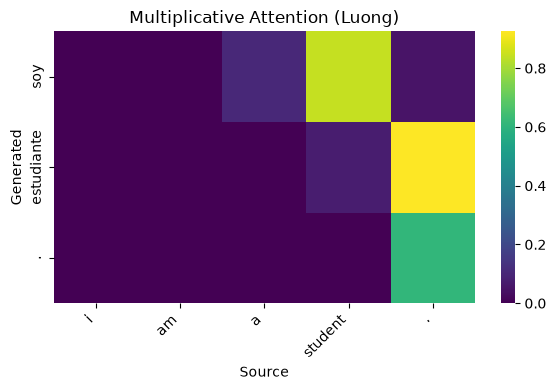

In [8]:
import seaborn as sns

sentence = "I am a student."
translation, attn = translate_sentence(sentence, english_vocab, spanish_vocab, model, device, max_len=config.MAX_DECODE_LEN)
src_tokens = english_vocab.tokenize(sentence)
trg_tokens = translation.split()
attn = attn[:len(trg_tokens), :len(src_tokens)].numpy()

plt.figure(figsize=(max(6, len(src_tokens) * 0.6), max(4, len(trg_tokens) * 0.6)))
sns.heatmap(attn, xticklabels=src_tokens, yticklabels=trg_tokens, cmap="viridis")
plt.xlabel("Source")
plt.ylabel("Generated")
plt.title(MODEL_NAME)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"../results/figures/{MODEL_KEY}_attention.png", dpi=150, bbox_inches="tight")
plt.show()